# 08. EDA de la base mensual operativa

Este notebook desarrolla un analisis descriptivo complementario de la base mensual final del proyecto.

## Objetivos
- describir la estructura y cobertura temporal de la base mensual
- explicar su papel metodologico dentro del proyecto
- analizar patrones estacionales de clima, satelite y cosecha
- revisar calidad, cobertura y faltantes esperados
- dejar insumos utiles para el informe tecnico y para futuras capas operativas del dashboard


## Comentario metodologico

Esta base mensual no reemplaza a la base anual de modelado. Su rol es complementario.

- La evidencia productiva observada mas solida del proyecto sigue estando a nivel anual.
- La base mensual sirve para entender estacionalidad, monitoreo, logica de cosecha y comportamiento de las señales climaticas y satelitales.
- Las variables productivas mensuales deben leerse como una capa operativa derivada del flujo anual cuando corresponda, no como una nueva verdad observada independiente.

Por eso este EDA se enfoca en describir la base, mostrar como se integra al proyecto y dejar claro que su uso principal es operativo y analitico complementario.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

MATPLOTLIB_AVAILABLE = True
SEABORN_AVAILABLE = True

try:
    import matplotlib.pyplot as plt
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    plt = None

try:
    import seaborn as sns
except ImportError:
    SEABORN_AVAILABLE = False
    sns = None

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 180)


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'BASE_DE_DATOS').exists():
            return candidate
    raise FileNotFoundError('No se encontro una carpeta BASE_DE_DATOS en la ruta actual ni en sus padres.')


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
BASE_DATOS = PROJECT_ROOT / 'BASE_DE_DATOS'
INPUT_PATH = BASE_DATOS / 'FINALES' / 'dataset_operativo_mensual_limpio.csv'


In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'No existe el archivo esperado: {INPUT_PATH}')

print('Rutas validadas correctamente.')
print('Matplotlib disponible:', MATPLOTLIB_AVAILABLE)
print('Seaborn disponible:', SEABORN_AVAILABLE)


Rutas validadas correctamente.
Matplotlib disponible: True
Seaborn disponible: True


## Carga de la base mensual final

Esta base contiene la capa mensual clima-satelite, los patrones de cosecha, la integracion economica y los metadatos de calidad necesarios para el uso operativo de la informacion.


In [3]:
df = pd.read_csv(INPUT_PATH, sep=';')
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df = df.sort_values(['departamento', 'fecha']).reset_index(drop=True)
df['periodo_agronet'] = np.where(df['tiene_observacion_agronet'].eq(1), 'observado_agronet', 'sin_observacion_agronet')

print('Shape base mensual final:', df.shape)
display(df.head(5))


Shape base mensual final: (628, 61)


,fecha,departamento,mes,anio,precipitation,temp_aire_C,humedad_relativa_pct,soil,def,pet,aet,GDD_cafe,NDVI,EVI,LST_Day_1km,LST_Night_1km,Gpp,Lai_500m,Fpar_500m,elevacion_media_m,elevacion_std_m,pendiente_media,pendiente_std,aspecto_medio,NDVI_anomalia_pct,EVI_anomalia_pct,Gpp_anomalia_pct,Lai_500m_anomalia_pct,precipitation_anomalia_pct,indice_perdida,evento_perdida,n_municipios,area_cosechada_ha,area_sembrada_ha,produccion_t_original,rendimiento_t_ha_original,produccion_t,rendimiento_t_ha,correccion_aplicada,motivo_correccion,delta_produccion_t,delta_rendimiento_t_ha,rendimiento_medio_municipal_reportado,dif_rendimiento_calculado_vs_reportado,rendimiento_medio_t_ha,produccion_media_t,factor_mensual_raw,factor_mensual,es_mes_cosecha,produccion_mensual_t,area_mensual_ha,perdida_real_pct,perdida_real_mensual_pct,evento_perdida_real,precio_ico_usd_ton,precio_productor_usd_ton,tiene_observacion_agronet,evento_perdida_real_disponible,anio_completo,cobertura_climatica_completa,periodo_agronet
0,2000-01-01,Cundinamarca,1,2000,58.122070,16.040529,80.992858,1030.010331,87.170530,969.042186,881.660989,7.203958,NaN,NaN,NaN,NaN,0.045104,NaN,NaN,1895.307361,1086.421734,14.454071,10.320921,185.295099,NaN,NaN,-15.291502,NaN,-6.983227,-15.291502,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,sin_correccion,NaN,NaN,NaN,NaN,NaN,NaN,0.040,0.042105,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,sin_observacion_agronet
1,2000-02-01,Cundinamarca,2,2000,102.480240,16.364601,77.921106,1096.139029,4.391722,1015.409971,1010.790421,7.418556,0.275704,0.194953,25.120398,7.237869,0.046012,1.003104,0.286976,1895.307361,1086.421734,14.454071,10.320921,185.295099,-50.827307,-44.414822,-2.640640,-43.957202,25.536483,-32.627589,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,sin_correccion,NaN,NaN,NaN,NaN,NaN,NaN,0.035,0.036842,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,sin_observacion_agronet
2,2000-03-01,Cundinamarca,3,2000,126.669177,16.723544,77.873874,1071.270787,24.697898,1135.673349,1110.807486,7.621710,0.504174,0.331648,23.907992,11.393505,0.044515,1.484609,0.373975,1895.307361,1086.421734,14.454071,10.320921,185.295099,-3.017617,-2.038318,2.444149,-7.367417,-10.835857,-0.870595,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,sin_correccion,NaN,NaN,NaN,NaN,NaN,NaN,0.045,0.047368,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,sin_observacion_agronet
3,2000-04-01,Cundinamarca,4,2000,146.966135,16.678842,81.240824,1098.622452,11.807117,990.875170,978.952966,7.806545,0.438807,0.307035,23.645491,6.576422,0.048026,1.149813,0.300540,1895.307361,1086.421734,14.454071,10.320921,185.295099,-15.700155,-12.968768,8.392347,-24.035019,-30.175531,-6.758859,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,sin_correccion,NaN,NaN,NaN,NaN,NaN,NaN,0.075,0.078947,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,sin_observacion_agronet
4,2000-05-01,Cundinamarca,5,2000,238.109657,16.730210,83.152572,1182.556733,0.000000,891.637309,891.514079,7.702863,0.430630,0.286162,23.446429,8.874900,0.049690,1.030764,0.267016,1895.307361,1086.421734,14.454071,10.320921,185.295099,-16.584008,-16.898203,3.782529,-34.932718,13.446331,-9.899894,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,sin_correccion,NaN,NaN,NaN,NaN,NaN,NaN,0.090,0.094737,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,sin_observacion_agronet


## Perfil general de la base

Primero resumimos su estructura general para ubicar su alcance temporal y su cobertura dentro del proyecto.


In [4]:
general_summary = pd.DataFrame([
    {'indicador': 'filas', 'valor': int(df.shape[0])},
    {'indicador': 'columnas', 'valor': int(df.shape[1])},
    {'indicador': 'departamentos', 'valor': int(df['departamento'].nunique())},
    {'indicador': 'fecha_min', 'valor': df['fecha'].min().strftime('%Y-%m')},
    {'indicador': 'fecha_max', 'valor': df['fecha'].max().strftime('%Y-%m')},
    {'indicador': 'filas_con_observacion_agronet', 'valor': int(df['tiene_observacion_agronet'].sum())},
    {'indicador': 'filas_sin_observacion_agronet', 'valor': int((1 - df['tiene_observacion_agronet']).sum())}
])

coverage_by_department = df.groupby('departamento').agg(
    fecha_min=('fecha', 'min'),
    fecha_max=('fecha', 'max'),
    filas=('fecha', 'count'),
    filas_observadas=('tiene_observacion_agronet', 'sum')
).reset_index()
coverage_by_department['fecha_min'] = coverage_by_department['fecha_min'].dt.strftime('%Y-%m')
coverage_by_department['fecha_max'] = coverage_by_department['fecha_max'].dt.strftime('%Y-%m')

display(general_summary)
display(coverage_by_department)


,indicador,valor
0,filas,628
1,columnas,61
2,departamentos,2
3,fecha_min,2000-01
4,fecha_max,2026-02
5,filas_con_observacion_agronet,432
6,filas_sin_observacion_agronet,196


,departamento,fecha_min,fecha_max,filas,filas_observadas
0,Cundinamarca,2000-01,2026-02,314,216
1,Risaralda,2000-01,2026-02,314,216


## Como se integra esta base al proyecto

Una parte central de este EDA es dejar claro como leer esta base dentro de la arquitectura de datos del proyecto.


In [5]:
integration_notes = pd.DataFrame([
    {'componente': 'clima y satelite mensual', 'rol_en_el_proyecto': 'observacion mensual base para estacionalidad, monitoreo y construccion de agregados'},
    {'componente': 'patron de cosecha y factor mensual', 'rol_en_el_proyecto': 'permite representar distribucion operativa intra-anual y apoyar logica de trigger'},
    {'componente': 'variables productivas anuales expandidas', 'rol_en_el_proyecto': 'sirven como puente operativo, pero no sustituyen la evidencia anual observada'},
    {'componente': 'perdida_real_mensual_pct', 'rol_en_el_proyecto': 'debe leerse con cautela como proxy operativa en meses aplicables, no como target principal del modelado formal'},
    {'componente': 'base anual limpia', 'rol_en_el_proyecto': 'sigue siendo la fuente principal para entrenamiento y validacion de modelos'}
])
display(integration_notes)


,componente,rol_en_el_proyecto
0,clima y satelite mensual,"observacion mensual base para estacionalidad, monitoreo y construccion de agregados"
1,patron de cosecha y factor mensual,permite representar distribucion operativa intra-anual y apoyar logica de trigger
2,variables productivas anuales expandidas,"sirven como puente operativo, pero no sustituyen la evidencia anual observada"
3,perdida_real_mensual_pct,"debe leerse con cautela como proxy operativa en meses aplicables, no como target principal del modelado formal"
4,base anual limpia,sigue siendo la fuente principal para entrenamiento y validacion de modelos


## Cobertura temporal y periodos observados

La base cubre una ventana mensual amplia, pero no toda la serie tiene la misma naturaleza. Es importante distinguir claramente los meses con observacion productiva asociada a Agronet y los meses que solo contienen la capa operativa clima-satelite.


In [6]:
months_per_year = df.groupby(['departamento', 'anio'])['mes'].nunique().reset_index(name='n_meses')
partial_years = months_per_year.loc[months_per_year['n_meses'] < 12].copy()
coverage_by_year = df.groupby('anio').agg(
    filas=('fecha', 'count'),
    filas_observadas_agronet=('tiene_observacion_agronet', 'sum'),
    filas_con_cobertura_climatica_completa=('cobertura_climatica_completa', 'sum')
).reset_index()

display(months_per_year.head(12))
display(partial_years if not partial_years.empty else pd.DataFrame({'mensaje': ['No hay anios parciales.']}))
display(coverage_by_year)


,departamento,anio,n_meses
0,Cundinamarca,2000,12
1,Cundinamarca,2001,12
2,Cundinamarca,2002,12
3,Cundinamarca,2003,12
4,Cundinamarca,2004,12
5,Cundinamarca,2005,12
6,Cundinamarca,2006,12
7,Cundinamarca,2007,12
8,Cundinamarca,2008,12
9,Cundinamarca,2009,12


,departamento,anio,n_meses
26,Cundinamarca,2026,2
53,Risaralda,2026,2


,anio,filas,filas_observadas_agronet,filas_con_cobertura_climatica_completa
0,2000,24,0,22
1,2001,24,0,24
2,2002,24,0,24
3,2003,24,0,24
4,2004,24,0,24
5,2005,24,0,24
6,2006,24,0,24
7,2007,24,24,24
8,2008,24,24,24
9,2009,24,24,24


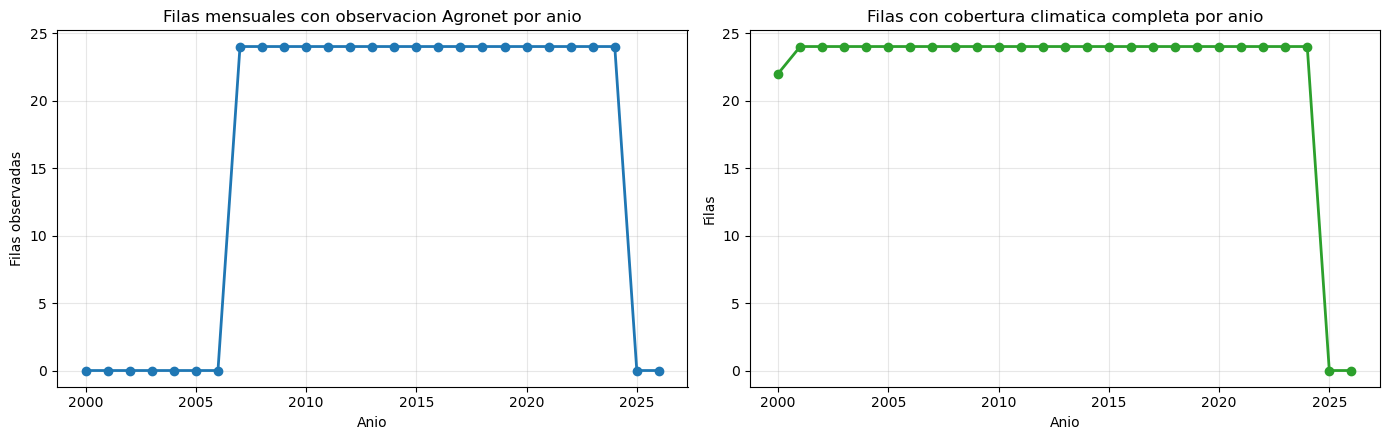

In [7]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(coverage_by_year['anio'], coverage_by_year['filas_observadas_agronet'], marker='o', linewidth=2)
    axes[0].set_title('Filas mensuales con observacion Agronet por anio')
    axes[0].set_xlabel('Anio')
    axes[0].set_ylabel('Filas observadas')
    axes[0].grid(alpha=0.3)

    axes[1].plot(coverage_by_year['anio'], coverage_by_year['filas_con_cobertura_climatica_completa'], marker='o', linewidth=2, color='#2ca02c')
    axes[1].set_title('Filas con cobertura climatica completa por anio')
    axes[1].set_xlabel('Anio')
    axes[1].set_ylabel('Filas')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No hay matplotlib disponible para graficar la cobertura temporal.')


## Estacionalidad climatica y satelital

Este bloque resume el comportamiento medio por mes para las variables mas representativas de clima y satelite. Aqui esta uno de los principales valores de la base mensual: permitir lectura intra-anual del sistema cafetero.


In [8]:
seasonal_cols = ['precipitation', 'temp_aire_C', 'humedad_relativa_pct', 'NDVI', 'EVI', 'Gpp', 'indice_perdida']
seasonal_summary = df.groupby(['departamento', 'mes'])[seasonal_cols].mean(numeric_only=True).reset_index()
display(seasonal_summary.head(24))


,departamento,mes,precipitation,temp_aire_C,humedad_relativa_pct,NDVI,EVI,Gpp,indice_perdida
0,Cundinamarca,1,62.485580,17.202743,74.979912,0.652768,0.396782,0.053246,-3.920898e-01
1,Cundinamarca,2,81.633830,17.604993,74.221151,0.560684,0.350728,0.047260,-6.832142e-16
2,Cundinamarca,3,142.062911,17.562606,78.075773,0.519861,0.338548,0.043453,-8.027766e-16
3,Cundinamarca,4,210.479416,17.319677,82.264469,0.520531,0.352788,0.044308,1.366428e-16
4,Cundinamarca,5,209.887489,17.170257,83.292057,0.516245,0.344352,0.047879,3.416071e-16
5,Cundinamarca,6,156.673027,16.842710,80.847115,0.528341,0.348881,0.050557,-1.127303e-15
6,Cundinamarca,7,132.810176,16.762674,78.299653,0.514599,0.341965,0.050994,1.093143e-15
7,Cundinamarca,8,124.513252,17.121523,74.962930,0.537658,0.354552,0.051208,5.192428e-15
8,Cundinamarca,9,127.301774,17.381341,74.659314,0.558439,0.374517,0.050004,4.440892e-16
9,Cundinamarca,10,208.463757,17.096657,80.775960,0.565954,0.376345,0.045399,-9.872445e-15


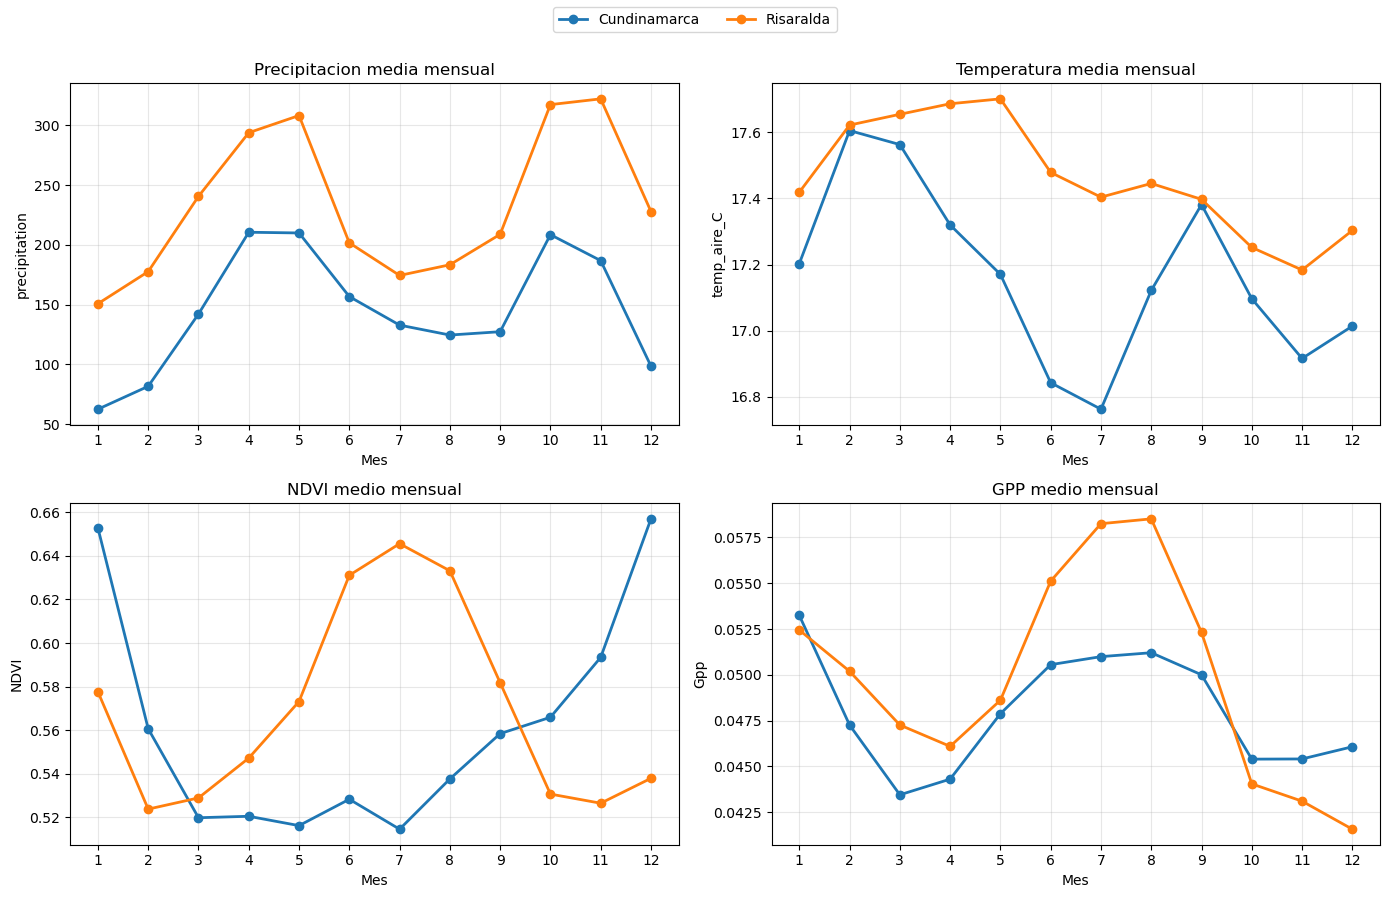

In [9]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()
    plot_specs = [
        ('precipitation', 'Precipitacion media mensual'),
        ('temp_aire_C', 'Temperatura media mensual'),
        ('NDVI', 'NDVI medio mensual'),
        ('Gpp', 'GPP medio mensual')
    ]
    colors = {'Cundinamarca': '#1f77b4', 'Risaralda': '#ff7f0e'}

    for ax, (col, title) in zip(axes, plot_specs):
        for dept, subdf in seasonal_summary.groupby('departamento'):
            ax.plot(subdf['mes'], subdf[col], marker='o', linewidth=2, label=dept, color=colors.get(dept))
        ax.set_title(title)
        ax.set_xlabel('Mes')
        ax.set_ylabel(col)
        ax.set_xticks(range(1, 13))
        ax.grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print('No hay matplotlib disponible para las graficas estacionales de clima y satelite.')


## Patron de cosecha y ponderacion mensual

La base mensual tambien permite describir explicitamente la distribucion intra-anual asociada al patron de cosecha. Esta capa es clave para la futura interpretacion operativa del seguro indexado.


In [10]:
cosecha_pattern = df.groupby(['departamento', 'mes']).agg(
    es_mes_cosecha=('es_mes_cosecha', 'max'),
    factor_mensual=('factor_mensual', 'mean'),
    factor_mensual_raw=('factor_mensual_raw', 'mean')
).reset_index()

factor_sums = df.groupby(['departamento', 'anio'])['factor_mensual'].sum().reset_index()
display(cosecha_pattern)
display(factor_sums.head(12))
display(factor_sums['factor_mensual'].describe().rename('factor_mensual').to_frame())


,departamento,mes,es_mes_cosecha,factor_mensual,factor_mensual_raw
0,Cundinamarca,1,0,0.042105,0.040
1,Cundinamarca,2,0,0.036842,0.035
2,Cundinamarca,3,0,0.047368,0.045
3,Cundinamarca,4,1,0.078947,0.075
4,Cundinamarca,5,1,0.094737,0.090
5,Cundinamarca,6,1,0.084211,0.080
6,Cundinamarca,7,0,0.057895,0.055
7,Cundinamarca,8,0,0.052632,0.050
8,Cundinamarca,9,0,0.063158,0.060
9,Cundinamarca,10,1,0.126316,0.120


,departamento,anio,factor_mensual
0,Cundinamarca,2000,1.0
1,Cundinamarca,2001,1.0
2,Cundinamarca,2002,1.0
3,Cundinamarca,2003,1.0
4,Cundinamarca,2004,1.0
5,Cundinamarca,2005,1.0
6,Cundinamarca,2006,1.0
7,Cundinamarca,2007,1.0
8,Cundinamarca,2008,1.0
9,Cundinamarca,2009,1.0


,factor_mensual
count,54.000000
mean,0.965887
std,0.175576
min,0.078947
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


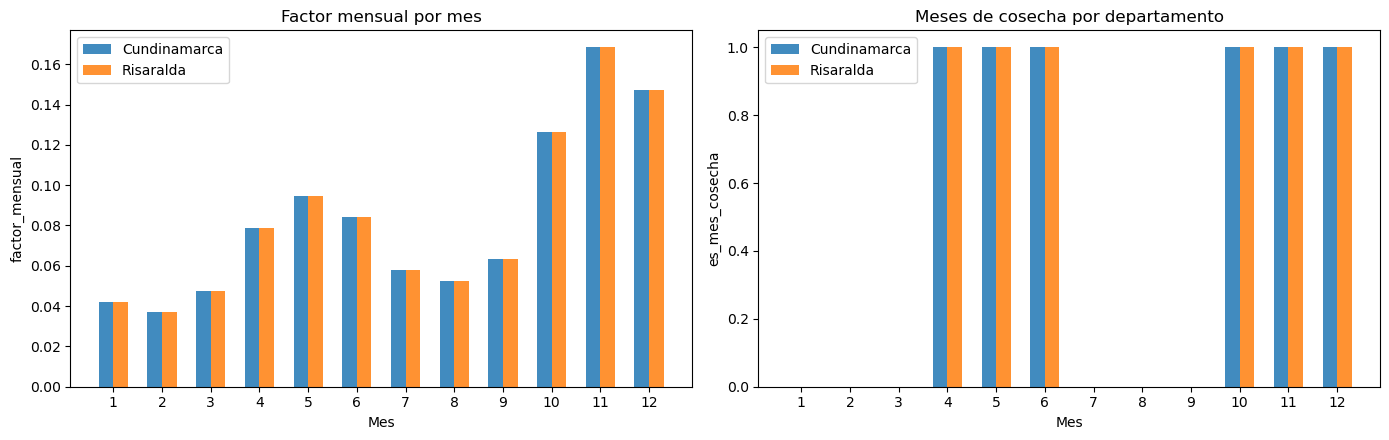

In [11]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    colors = {'Cundinamarca': '#1f77b4', 'Risaralda': '#ff7f0e'}

    for dept, subdf in cosecha_pattern.groupby('departamento'):
        axes[0].bar(subdf['mes'] + (-0.15 if dept == 'Cundinamarca' else 0.15), subdf['factor_mensual'], width=0.3, label=dept, color=colors.get(dept), alpha=0.85)
    axes[0].set_title('Factor mensual por mes')
    axes[0].set_xlabel('Mes')
    axes[0].set_ylabel('factor_mensual')
    axes[0].set_xticks(range(1, 13))
    axes[0].legend()

    for dept, subdf in cosecha_pattern.groupby('departamento'):
        axes[1].bar(subdf['mes'] + (-0.15 if dept == 'Cundinamarca' else 0.15), subdf['es_mes_cosecha'], width=0.3, label=dept, color=colors.get(dept), alpha=0.85)
    axes[1].set_title('Meses de cosecha por departamento')
    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel('es_mes_cosecha')
    axes[1].set_xticks(range(1, 13))
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No hay matplotlib disponible para las graficas del patron de cosecha.')


## Capa productiva mensual y su interpretacion

Aqui revisamos como se comportan las variables productivas mensuales dentro de la base. La lectura debe hacerse con cuidado:

- la disponibilidad de estas variables depende de la ventana observada asociada a Agronet
- `perdida_real_mensual_pct` solo existe cuando el flujo operativo la deja definida
- por eso esta capa sirve mas para analisis operativo que para definir directamente el target principal del modelo formal


In [12]:
productive_monthly_summary = pd.DataFrame([
    {'indicador': 'filas_con_produccion_mensual_t', 'valor': int(df['produccion_mensual_t'].notna().sum())},
    {'indicador': 'filas_con_area_mensual_ha', 'valor': int(df['area_mensual_ha'].notna().sum())},
    {'indicador': 'filas_con_perdida_real_pct', 'valor': int(df['perdida_real_pct'].notna().sum())},
    {'indicador': 'filas_con_perdida_real_mensual_pct', 'valor': int(df['perdida_real_mensual_pct'].notna().sum())},
    {'indicador': 'filas_cosecha', 'valor': int(df['es_mes_cosecha'].sum())}
])

proxy_by_month = df.groupby(['departamento', 'mes']).agg(
    n_filas=('fecha', 'count'),
    n_con_perdida_mensual=('perdida_real_mensual_pct', lambda s: int(s.notna().sum())),
    promedio_produccion_mensual_t=('produccion_mensual_t', 'mean'),
    promedio_area_mensual_ha=('area_mensual_ha', 'mean')
).reset_index()

display(productive_monthly_summary)
display(proxy_by_month.head(24))


,indicador,valor
0,filas_con_produccion_mensual_t,432
1,filas_con_area_mensual_ha,432
2,filas_con_perdida_real_pct,432
3,filas_con_perdida_real_mensual_pct,216
4,filas_cosecha,312


,departamento,mes,n_filas,n_con_perdida_mensual,promedio_produccion_mensual_t,promedio_area_mensual_ha
0,Cundinamarca,1,27,0,1263.905014,1395.378158
1,Cundinamarca,2,27,0,1105.916887,1220.955888
2,Cundinamarca,3,26,0,1421.893141,1569.800428
3,Cundinamarca,4,26,18,2369.821902,2616.334047
4,Cundinamarca,5,26,18,2843.786282,3139.600856
5,Cundinamarca,6,26,18,2527.810028,2790.756316
6,Cundinamarca,7,26,0,1737.869394,1918.644968
7,Cundinamarca,8,26,0,1579.881268,1744.222698
8,Cundinamarca,9,26,0,1895.857521,2093.067237
9,Cundinamarca,10,26,18,3791.715042,4186.134475


## Calidad y faltantes

Una parte importante de esta base es que sus faltantes no significan automaticamente error. Algunos son esperados por construccion del pipeline y por cobertura temporal de las fuentes.


In [13]:
nulls_top = df.isna().sum().sort_values(ascending=False).head(20).rename('nulos').reset_index().rename(columns={'index': 'variable'})

quality_flags = pd.DataFrame([
    {'indicador': 'filas_anio_completo', 'valor': int(df['anio_completo'].sum())},
    {'indicador': 'filas_cobertura_climatica_completa', 'valor': int(df['cobertura_climatica_completa'].sum())},
    {'indicador': 'filas_evento_perdida_real_disponible', 'valor': int(df['evento_perdida_real_disponible'].sum())},
    {'indicador': 'filas_corregidas', 'valor': int(df['correccion_aplicada'].sum())}
])

retained_missingness = pd.DataFrame([
    {'caso': 'variables productivas fuera de Agronet', 'lectura': 'Esperado en meses sin observacion productiva anual asociada'},
    {'caso': 'perdida_real_mensual_pct', 'lectura': 'Esperado fuera de meses operativos donde el proxy mensual aplica'},
    {'caso': 'faltantes climaticos residuales', 'lectura': 'Concentrados en cola final de algunas series y ya documentados en QC'}
])

display(nulls_top)
display(quality_flags)
display(retained_missingness)


,variable,nulos
0,perdida_real_mensual_pct,412
1,delta_rendimiento_t_ha,196
2,rendimiento_medio_municipal_reportado,196
3,rendimiento_medio_t_ha,196
4,area_mensual_ha,196
5,area_sembrada_ha,196
6,delta_produccion_t,196
7,produccion_t,196
8,rendimiento_t_ha_original,196
9,evento_perdida_real,196


,indicador,valor
0,filas_anio_completo,624
1,filas_cobertura_climatica_completa,598
2,filas_evento_perdida_real_disponible,432
3,filas_corregidas,12


,caso,lectura
0,variables productivas fuera de Agronet,Esperado en meses sin observacion productiva anual asociada
1,perdida_real_mensual_pct,Esperado fuera de meses operativos donde el proxy mensual aplica
2,faltantes climaticos residuales,Concentrados en cola final de algunas series y ya documentados en QC


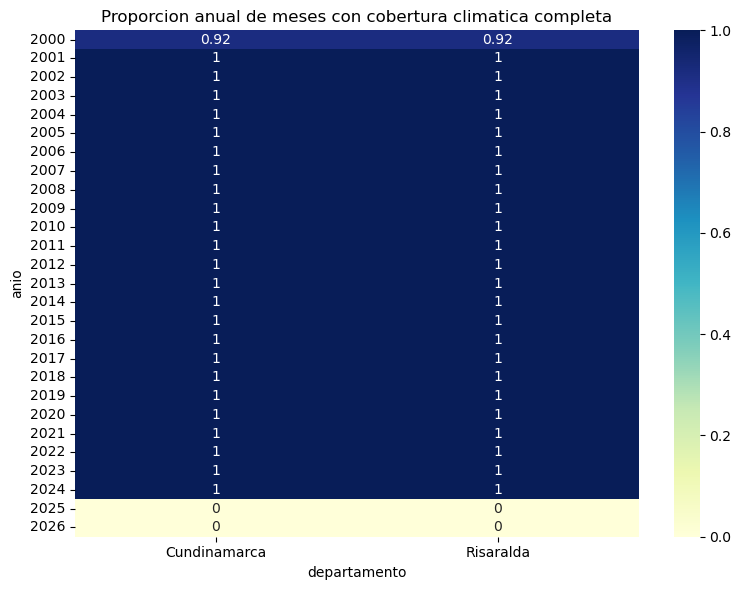

In [14]:
if MATPLOTLIB_AVAILABLE and SEABORN_AVAILABLE:
    climate_coverage = df.groupby(['departamento', 'anio'])['cobertura_climatica_completa'].mean().reset_index()
    pivot_cov = climate_coverage.pivot(index='anio', columns='departamento', values='cobertura_climatica_completa')
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_cov, annot=True, cmap='YlGnBu', vmin=0, vmax=1)
    plt.title('Proporcion anual de meses con cobertura climatica completa')
    plt.tight_layout()
    plt.show()
elif MATPLOTLIB_AVAILABLE:
    climate_coverage = df.groupby(['departamento', 'anio'])['cobertura_climatica_completa'].mean().reset_index()
    pivot_cov = climate_coverage.pivot(index='anio', columns='departamento', values='cobertura_climatica_completa')
    plt.figure(figsize=(8, 6))
    plt.imshow(pivot_cov, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
    plt.xticks(range(len(pivot_cov.columns)), pivot_cov.columns)
    plt.yticks(range(len(pivot_cov.index)), pivot_cov.index)
    plt.colorbar()
    plt.title('Proporcion anual de meses con cobertura climatica completa')
    plt.tight_layout()
    plt.show()
else:
    print('No hay librerias graficas disponibles para la visualizacion de cobertura climatica.')


## Lectura de cierre

Con esta exploracion complementaria ya podemos usar la base mensual con mas claridad en el informe tecnico y en el desarrollo posterior del proyecto.


In [15]:
closing_points = pd.DataFrame([
    {'tema': 'rol_metodologico', 'lectura': 'La base mensual fortalece la comprension estacional y operativa del proyecto, pero no sustituye la base anual para modelado formal.'},
    {'tema': 'cobertura', 'lectura': 'La serie mensual cubre de 2000-01 a 2026-02, mientras que la ventana asociada a observacion productiva de Agronet se concentra en 2007-2024.'},
    {'tema': 'estacionalidad', 'lectura': 'La base permite observar patron de cosecha, precipitacion, temperatura y dinamica satelital por mes y por departamento.'},
    {'tema': 'calidad', 'lectura': 'Los faltantes mas importantes son esperados por construccion del flujo y deben interpretarse en funcion del periodo y del rol de cada variable.'},
    {'tema': 'uso_en_el_proyecto', 'lectura': 'Esta base sera especialmente util para el informe tecnico, el dashboard y la futura interpretacion operativa del trigger.'}
])
display(closing_points)
print('Notebook 08 listo.')


,tema,lectura
0,rol_metodologico,"La base mensual fortalece la comprension estacional y operativa del proyecto, pero no sustituye la base anual para modelado formal."
1,cobertura,"La serie mensual cubre de 2000-01 a 2026-02, mientras que la ventana asociada a observacion productiva de Agronet se concentra en 2007-2024."
2,estacionalidad,"La base permite observar patron de cosecha, precipitacion, temperatura y dinamica satelital por mes y por departamento."
3,calidad,Los faltantes mas importantes son esperados por construccion del flujo y deben interpretarse en funcion del periodo y del rol de cada variable.
4,uso_en_el_proyecto,"Esta base sera especialmente util para el informe tecnico, el dashboard y la futura interpretacion operativa del trigger."


Notebook 08 listo.
